# Étape 3 — Réalisez une analyse non supervisée

**Projet 10** — Labellisez et appliquez des approches semi-supervisées en traitement d'images  
**Auteur :** David MEDRAGH — Mai 2026

---

## Objectif

Dans cette étape, je réduis la dimensionnalité des features extraites à l'étape 2, j'applique des méthodes de clustering pour identifier des regroupements naturels, et je produis une labellisation "faible" des 1 406 images non labellisées.

## Rappel de la mission

Je dispose de 2 048 features par image (extraites par ResNet50). Mon objectif est d'identifier 2 clusters (cancer / normal) de manière non supervisée, puis d'attribuer des pseudo-labels aux images sans label.

## ⚠️ Séparation stricte

**Je ne mélange jamais le jeu fortement labellisé (100 images) avec le jeu faiblement labellisé (produit par clustering).** Les 100 labels annotés par les radiologues servent uniquement à :
- calculer le score ARI pour évaluer la qualité du clustering
- mapper les clusters vers les classes (cancer/normal)

## Definition of done

- [ ] Les features sont standardisées (mean≈0, std≈1)
- [ ] La variance expliquée PCA est documentée
- [ ] PCA 2D et t-SNE 2D produisent des visualisations exploitables
- [ ] t-SNE est présenté comme outil de visualisation, pas de clustering
- [ ] K-Means (k=2) est appliqué sur les 1 506 images
- [ ] DBSCAN est appliqué sur l'espace PCA 50D
- [ ] Le score ARI est calculé sur les 100 images fortement labellisées
- [ ] La correspondance cluster → classe est établie par vote majoritaire
- [ ] Les pseudo-labels sont attribués aux 1 406 images non labellisées
- [ ] Le jeu faiblement labellisé est sauvegardé SÉPARÉMENT (`metadata_weak_labels.csv`)
- [ ] Des graphes 2D illustrant les clusters sont produits et commentés
- [ ] `random_state=42` est utilisé systématiquement

## Stack technique

_Infographie à ajouter._

## Imports et versions

Je charge les bibliothèques nécessaires à cette étape :
- **scikit-learn** : StandardScaler, PCA, t-SNE, K-Means, DBSCAN, ARI (recommandé par l'école)
- **seaborn** : scatter plots statistiques (recommandé par l'école)
- **plotly** : visualisation interactive des clusters (recommandé par l'école)
- **matplotlib** : figures statiques
- **numpy / pandas** : manipulation des données

In [1]:
# Suppression des avertissements non critiques
import warnings
warnings.filterwarnings('ignore')

# --- Bibliothèques standard ---
from pathlib import Path

# --- Bibliothèques scientifiques ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# --- Machine Learning ---
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score

# Constante de reproductibilité
RANDOM_STATE = 42

# Affichage des versions
print(f"scikit-learn : {sklearn.__version__}")
print(f"seaborn      : {sns.__version__}")
print(f"NumPy        : {np.__version__}")
print(f"pandas       : {pd.__version__}")

# Chargement des features et métadonnées produites à l'étape 2
FEATURES_DIR = Path("data/features")
features = np.load(FEATURES_DIR / "features.npy")
metadata = pd.read_csv(FEATURES_DIR / "metadata.csv")

print(f"\nFeatures     : {features.shape}")
print(f"Métadonnées  : {len(metadata)} lignes")
print(f"Labellisées  : {metadata['is_labeled'].sum()}")
print(f"Sans label   : {(~metadata['is_labeled']).sum()}")

scikit-learn : 1.8.0
seaborn      : 0.13.2
NumPy        : 2.4.4
pandas       : 3.0.3

Features     : (1506, 2048)
Métadonnées  : 1506 lignes
Labellisées  : 100
Sans label   : 1406


## Standardisation des features

Les features extraites par ResNet50 sont des sorties de ReLU : elles sont positives et non centrées. Avant d'appliquer PCA ou un algorithme de clustering, je les standardise (mean=0, std=1) pour que chaque dimension ait le même poids dans les calculs de distance.

In [2]:
# Standardisation : centrer-réduire les 2048 features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Vérification
print(f"Avant standardisation :")
print(f"  Mean : {features.mean():.4f}, Std : {features.std():.4f}")
print(f"\nAprès standardisation :")
print(f"  Mean : {features_scaled.mean():.6f}, Std : {features_scaled.std():.4f}")
print(f"  Min  : {features_scaled.min():.4f}, Max : {features_scaled.max():.4f}")

Avant standardisation :
  Mean : 0.1007, Std : 0.3043

Après standardisation :
  Mean : 0.000000, Std : 1.0000
  Min  : -2.6967, Max : 38.1024


## Analyse de la variance expliquée (PCA)

Avant de réduire la dimension, j'examine combien de composantes PCA sont nécessaires pour capturer l'essentiel de la variance. Cela me permet de choisir le nombre de composantes pour la réduction intermédiaire (utilisée ensuite par t-SNE et DBSCAN).

Variance totale expliquée par 100 composantes : 58.14%
Variance expliquée par 50 composantes : 46.17%
90% de variance : non atteint avec 100 composantes
95% de variance : non atteint avec 100 composantes


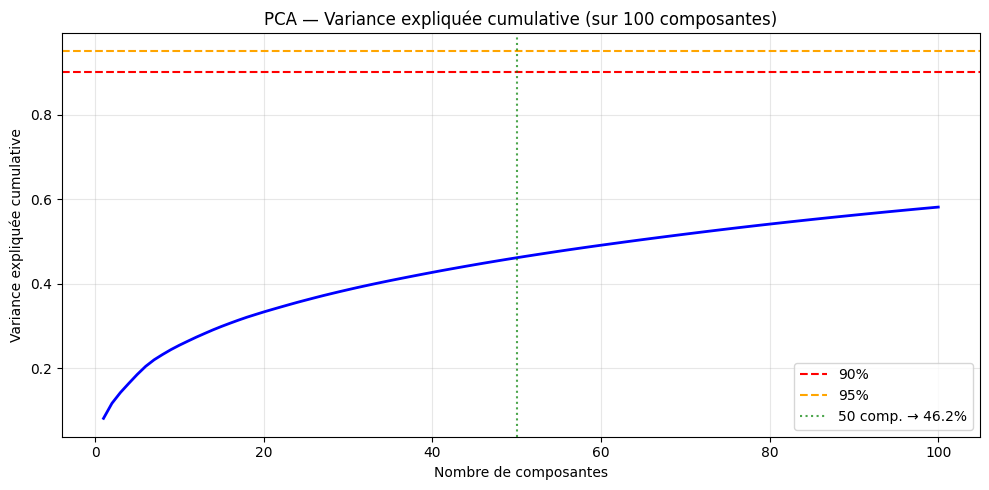

In [3]:
# PCA avec 100 composantes pour étudier la variance expliquée
pca_variance = PCA(n_components=100, random_state=RANDOM_STATE)
pca_variance.fit(features_scaled)

# Variance expliquée cumulative
variance_cumulative = np.cumsum(pca_variance.explained_variance_ratio_)

# Trouver le nombre de composantes pour 90% et 95% (gestion du cas non atteint)
if variance_cumulative[-1] >= 0.90:
    n_90 = np.argmax(variance_cumulative >= 0.90) + 1
else:
    n_90 = None
if variance_cumulative[-1] >= 0.95:
    n_95 = np.argmax(variance_cumulative >= 0.95) + 1
else:
    n_95 = None

print(f"Variance totale expliquée par 100 composantes : {variance_cumulative[-1]:.2%}")
print(f"Variance expliquée par 50 composantes : {variance_cumulative[49]:.2%}")
if n_90:
    print(f"Composantes pour 90% de variance : {n_90}")
else:
    print(f"90% de variance : non atteint avec 100 composantes")
if n_95:
    print(f"Composantes pour 95% de variance : {n_95}")
else:
    print(f"95% de variance : non atteint avec 100 composantes")

# Courbe de variance expliquée cumulative
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, 101), variance_cumulative, 'b-', linewidth=2)
ax.axhline(y=0.90, color='r', linestyle='--', label='90%')
ax.axhline(y=0.95, color='orange', linestyle='--', label='95%')
ax.axvline(x=50, color='green', linestyle=':', alpha=0.7, label=f'50 comp. → {variance_cumulative[49]:.1%}')
ax.set_xlabel('Nombre de composantes')
ax.set_ylabel('Variance expliquée cumulative')
ax.set_title('PCA — Variance expliquée cumulative (sur 100 composantes)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Visualisation PCA 2D

Je projette les 1 506 images dans un espace à 2 dimensions pour visualiser la structure globale du dataset. Les 100 images fortement labellisées sont colorées (cancer/normal), les 1 406 sans label sont en gris.

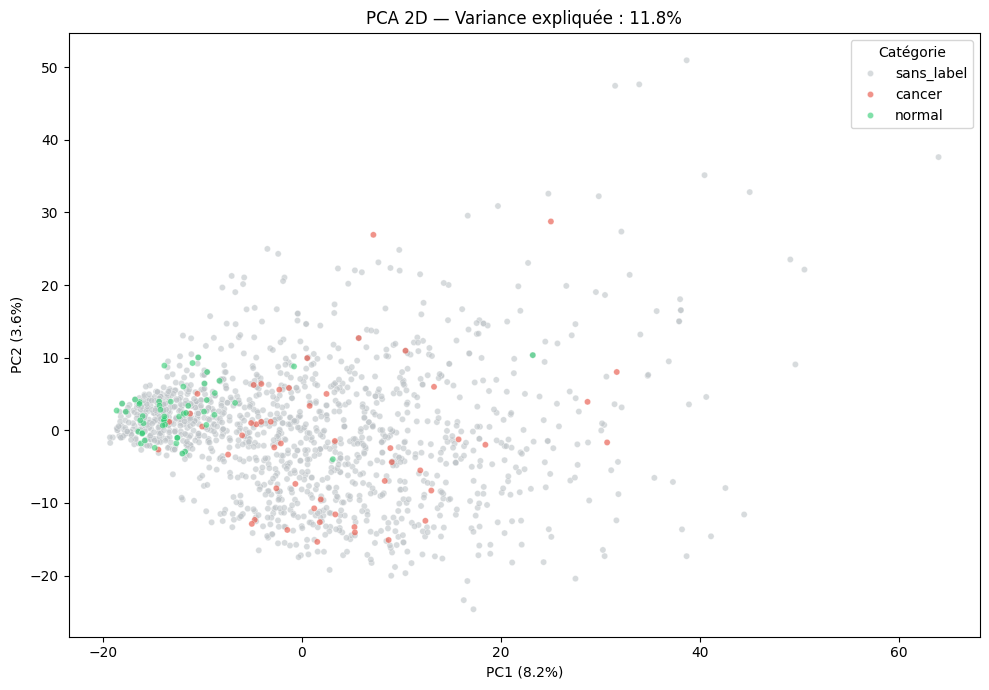

Variance expliquée PC1 + PC2 : 11.75%


In [4]:
# PCA 2D pour visualisation
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
features_pca_2d = pca_2d.fit_transform(features_scaled)

# Ajouter les coordonnées PCA au DataFrame
metadata['pca_1'] = features_pca_2d[:, 0]
metadata['pca_2'] = features_pca_2d[:, 1]

# Colonne de couleur pour le scatter (label_name ou 'sans_label')
metadata['categorie'] = metadata['label_name'].fillna('sans_label')

# Scatter plot seaborn
fig, ax = plt.subplots(figsize=(10, 7))
palette = {'cancer': '#e74c3c', 'normal': '#2ecc71', 'sans_label': '#bdc3c7'}
order = ['sans_label', 'cancer', 'normal']  # Sans label en fond

sns.scatterplot(
    data=metadata.sort_values('categorie', key=lambda x: x.map({'sans_label': 0, 'cancer': 1, 'normal': 2})),
    x='pca_1', y='pca_2', hue='categorie', palette=palette,
    alpha=0.6, s=20, ax=ax
)
ax.set_title(f'PCA 2D — Variance expliquée : {pca_2d.explained_variance_ratio_.sum():.1%}')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
ax.legend(title='Catégorie')
plt.tight_layout()
plt.show()

print(f"Variance expliquée PC1 + PC2 : {pca_2d.explained_variance_ratio_.sum():.2%}")

## PCA intermédiaire (50D)

Je réduis d'abord les features de 2 048 à 50 dimensions. Cette réduction intermédiaire sert de base pour :
- **t-SNE** : qui ne fonctionne bien qu'en dimension modérée
- **DBSCAN** : dont les distances euclidiennes deviennent instables en très haute dimension

50 composantes est un bon compromis entre conservation de l'information et réduction du bruit.

In [5]:
# PCA intermédiaire : 2048 → 50 dimensions
pca_50d = PCA(n_components=50, random_state=RANDOM_STATE)
features_pca_50d = pca_50d.fit_transform(features_scaled)

print(f"Shape après PCA 50D : {features_pca_50d.shape}")
print(f"Variance expliquée cumulée (50 comp.) : {pca_50d.explained_variance_ratio_.sum():.2%}")

Shape après PCA 50D : (1506, 50)
Variance expliquée cumulée (50 comp.) : 46.13%


## Visualisation t-SNE 2D

t-SNE (t-distributed Stochastic Neighbor Embedding) est un algorithme de réduction non linéaire qui préserve les voisinages locaux. Il est utilisé ici **uniquement pour la visualisation** — je ne base pas le choix de mon clustering sur l'apparence du nuage t-SNE.

Je l'applique sur les 50 composantes PCA (pas sur les 2 048 features brutes) pour des raisons de performance et de qualité.

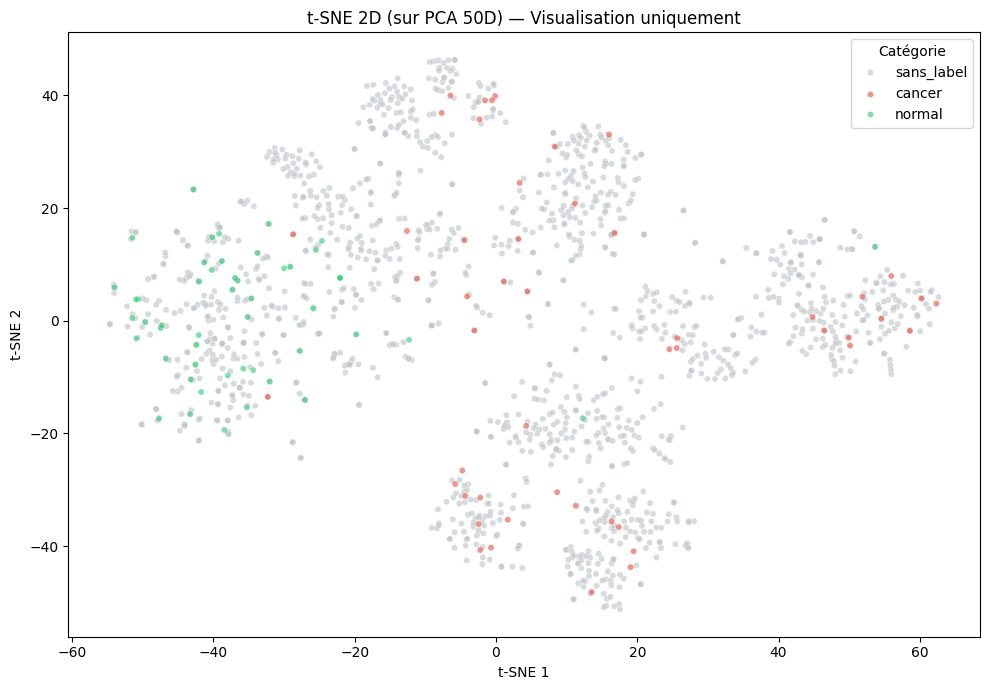

In [6]:
# t-SNE 2D sur les 50 composantes PCA
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, max_iter=1000)
features_tsne = tsne.fit_transform(features_pca_50d)

# Ajouter les coordonnées t-SNE au DataFrame
metadata['tsne_1'] = features_tsne[:, 0]
metadata['tsne_2'] = features_tsne[:, 1]

# Scatter plot seaborn
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=metadata.sort_values('categorie', key=lambda x: x.map({'sans_label': 0, 'cancer': 1, 'normal': 2})),
    x='tsne_1', y='tsne_2', hue='categorie', palette=palette,
    alpha=0.6, s=20, ax=ax
)
ax.set_title('t-SNE 2D (sur PCA 50D) — Visualisation uniquement')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(title='Catégorie')
plt.tight_layout()
plt.show()

# Plotly interactif (recommandé par l'école)
fig_plotly = px.scatter(
    metadata, x='tsne_1', y='tsne_2', color='categorie',
    color_discrete_map=palette,
    title='t-SNE 2D — Vue interactive (plotly)',
    hover_data=['filename', 'dossier', 'label_name'],
    opacity=0.6,
)
fig_plotly.show()

## Clustering K-Means (k=2)

J'applique K-Means avec 2 clusters sur les features standardisées complètes (2 048 dimensions). Le choix de k=2 est imposé par l'école : il correspond au nombre de classes du dataset labellisé (cancer/normal).

K-Means est un algorithme de partitionnement qui minimise la variance intra-cluster. Il fonctionne bien sur des espaces de grande dimension quand les clusters sont globalement séparables.

In [7]:
# K-Means avec k=2 sur les features standardisées complètes
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans.fit_predict(features_scaled)

# Ajouter les labels K-Means au DataFrame
metadata['cluster_kmeans'] = kmeans_labels

# Distribution des clusters
print("Distribution K-Means :")
print(metadata['cluster_kmeans'].value_counts().sort_index())
print(f"\nInertie : {kmeans.inertia_:.2f}")

Distribution K-Means :
cluster_kmeans
0    582
1    924
Name: count, dtype: int64

Inertie : 2914166.75


## Clustering DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) est un algorithme basé sur la densité qui ne nécessite pas de fixer le nombre de clusters à l'avance. Il peut aussi identifier des points "bruit" (label=-1) qui n'appartiennent à aucun cluster.

Je l'applique sur l'espace PCA 50D (pas sur les 2 048 dimensions brutes) car les distances euclidiennes deviennent instables en très haute dimension.

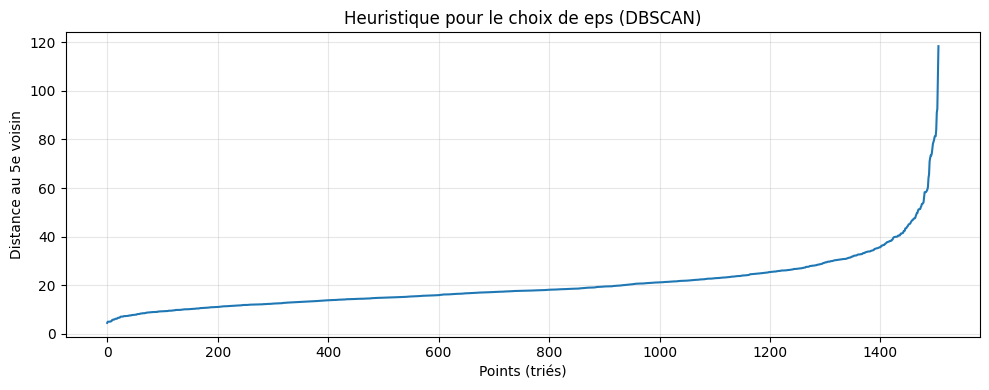

eps choisi (médiane des distances au 5e voisin) : 17.75

Clusters trouvés : 1
Points bruit (-1) : 618 (41.0%)

Distribution DBSCAN :
cluster_dbscan
-1    618
 0    888
Name: count, dtype: int64


In [8]:
# DBSCAN sur PCA 50D — exploration de paramètres
# Je teste plusieurs valeurs d'eps pour trouver un bon compromis
from sklearn.neighbors import NearestNeighbors

# Heuristique : utiliser la distance au k-ième voisin pour estimer eps
nn = NearestNeighbors(n_neighbors=5)
nn.fit(features_pca_50d)
distances, _ = nn.kneighbors(features_pca_50d)
distances_k = np.sort(distances[:, -1])  # Distance au 5e voisin

# Courbe des distances pour choisir eps (méthode du coude)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(distances_k)
ax.set_xlabel('Points (triés)')
ax.set_ylabel('Distance au 5e voisin')
ax.set_title('Heuristique pour le choix de eps (DBSCAN)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Choix d'eps basé sur le coude observé
# Je prends la médiane des distances comme point de départ
eps_value = np.median(distances_k)
print(f"eps choisi (médiane des distances au 5e voisin) : {eps_value:.2f}")

# DBSCAN
dbscan = DBSCAN(eps=eps_value, min_samples=5)
dbscan_labels = dbscan.fit_predict(features_pca_50d)

metadata['cluster_dbscan'] = dbscan_labels

# Résultats
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_bruit = (dbscan_labels == -1).sum()
print(f"\nClusters trouvés : {n_clusters_dbscan}")
print(f"Points bruit (-1) : {n_bruit} ({n_bruit/len(dbscan_labels):.1%})")
print(f"\nDistribution DBSCAN :")
print(metadata['cluster_dbscan'].value_counts().sort_index())

## Visualisation des clusters

Je projette les résultats de K-Means et DBSCAN sur les espaces PCA 2D et t-SNE 2D pour visualiser la qualité de la séparation.

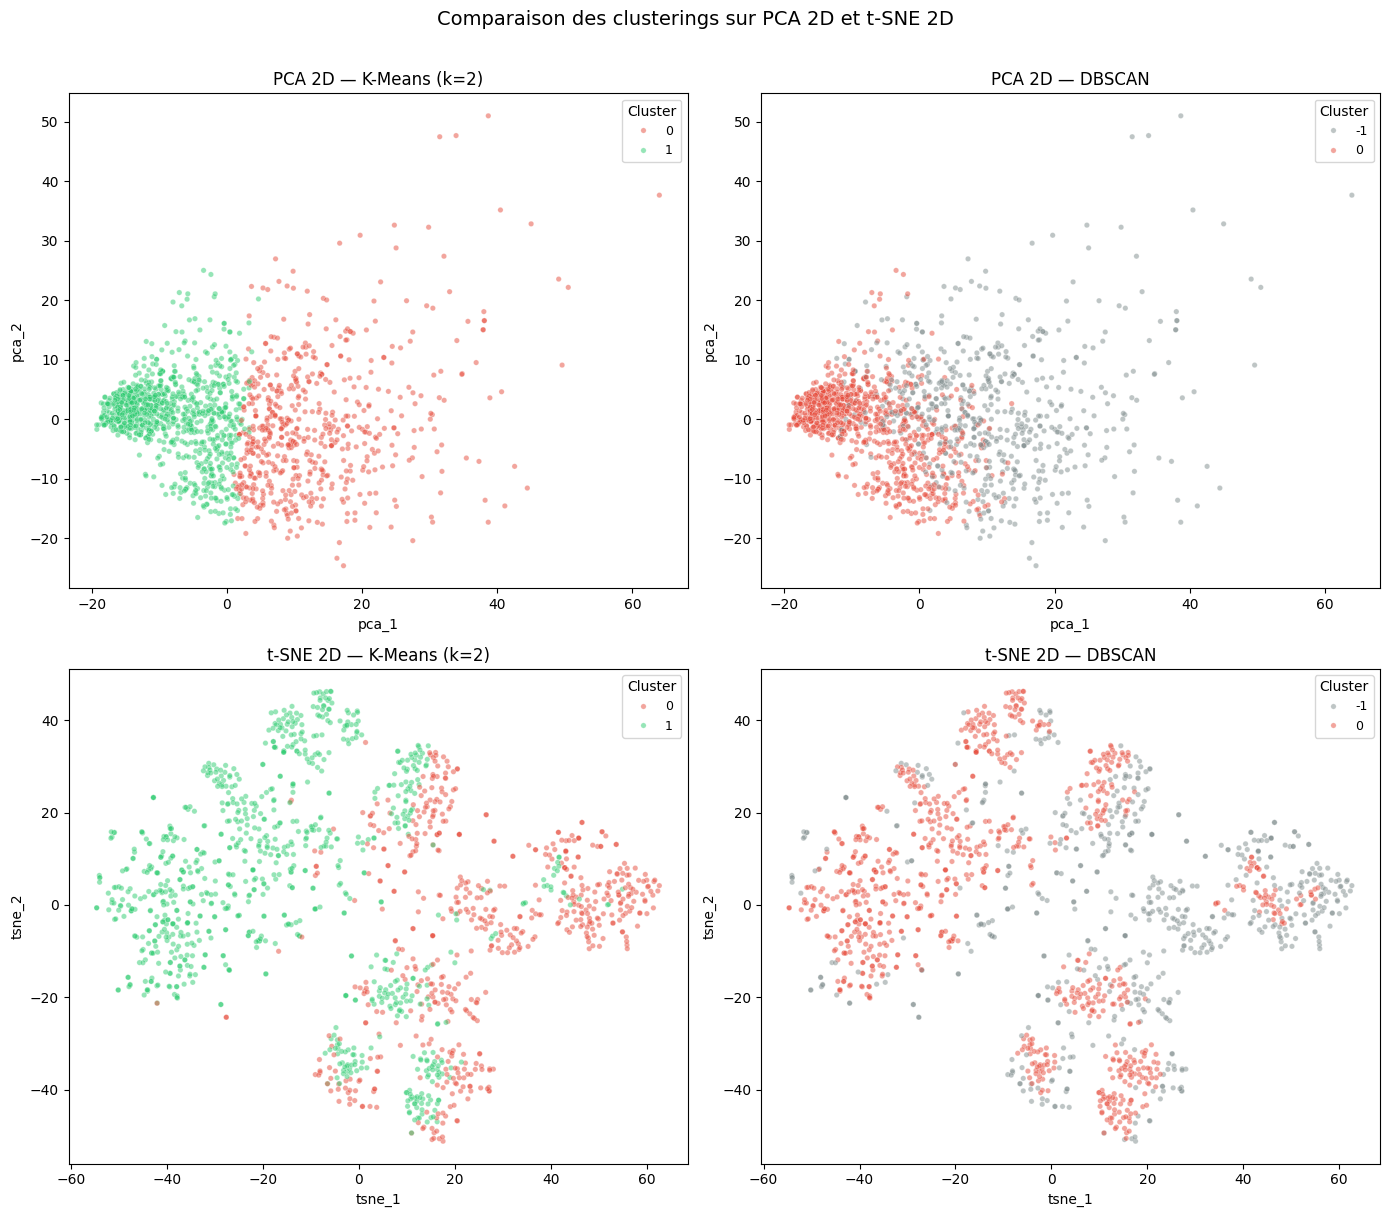

In [9]:
# Visualisation : 2×2 (PCA/t-SNE × K-Means/DBSCAN)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Palette pour les clusters
palette_clusters = {0: '#e74c3c', 1: '#2ecc71', -1: '#7f8c8d'}

# PCA 2D + K-Means
sns.scatterplot(
    data=metadata, x='pca_1', y='pca_2',
    hue='cluster_kmeans', palette={0: '#e74c3c', 1: '#2ecc71'},
    alpha=0.5, s=15, ax=axes[0, 0], legend='full'
)
axes[0, 0].set_title('PCA 2D — K-Means (k=2)')

# PCA 2D + DBSCAN
sns.scatterplot(
    data=metadata, x='pca_1', y='pca_2',
    hue='cluster_dbscan', palette=palette_clusters,
    alpha=0.5, s=15, ax=axes[0, 1], legend='full'
)
axes[0, 1].set_title('PCA 2D — DBSCAN')

# t-SNE 2D + K-Means
sns.scatterplot(
    data=metadata, x='tsne_1', y='tsne_2',
    hue='cluster_kmeans', palette={0: '#e74c3c', 1: '#2ecc71'},
    alpha=0.5, s=15, ax=axes[1, 0], legend='full'
)
axes[1, 0].set_title('t-SNE 2D — K-Means (k=2)')

# t-SNE 2D + DBSCAN
sns.scatterplot(
    data=metadata, x='tsne_1', y='tsne_2',
    hue='cluster_dbscan', palette=palette_clusters,
    alpha=0.5, s=15, ax=axes[1, 1], legend='full'
)
axes[1, 1].set_title('t-SNE 2D — DBSCAN')

for ax in axes.flat:
    ax.legend(title='Cluster', fontsize=9)

plt.suptitle('Comparaison des clusterings sur PCA 2D et t-SNE 2D', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Score ARI (Adjusted Rand Index)

L'ARI mesure l'alignement entre les clusters prédits et les vrais labels. Il vaut :
- **1.0** : accord parfait
- **0.0** : clustering aléatoire
- **<0** : pire que le hasard

Je le calcule **uniquement sur les 100 images fortement labellisées** (les seules pour lesquelles j'ai la vérité terrain). L'école précise de ne pas s'attendre à un résultat parfait.

In [10]:
# Masque : uniquement les 100 images fortement labellisées
mask_labeled = metadata['is_labeled'] == True
y_true = metadata.loc[mask_labeled, 'label_id'].astype(int).values

# ARI pour K-Means
y_pred_kmeans = metadata.loc[mask_labeled, 'cluster_kmeans'].values
ari_kmeans = adjusted_rand_score(y_true, y_pred_kmeans)

# ARI pour DBSCAN (uniquement sur les images labellisées qui ne sont pas du bruit)
mask_labeled_no_bruit = mask_labeled & (metadata['cluster_dbscan'] != -1)
if mask_labeled_no_bruit.sum() > 0:
    y_true_dbscan = metadata.loc[mask_labeled_no_bruit, 'label_id'].astype(int).values
    y_pred_dbscan = metadata.loc[mask_labeled_no_bruit, 'cluster_dbscan'].values
    ari_dbscan = adjusted_rand_score(y_true_dbscan, y_pred_dbscan)
    n_labeled_bruit = mask_labeled.sum() - mask_labeled_no_bruit.sum()
else:
    ari_dbscan = None
    n_labeled_bruit = mask_labeled.sum()

print("═" * 50)
print("Score ARI (sur les 100 images fortement labellisées)")
print("═" * 50)
print(f"\nK-Means (k=2)  : ARI = {ari_kmeans:.4f}")
if ari_dbscan is not None:
    print(f"DBSCAN         : ARI = {ari_dbscan:.4f} (excluant {n_labeled_bruit} images classées bruit)")
else:
    print(f"DBSCAN         : Non calculable (toutes les images labellisées classées en bruit)")

# Interprétation
print(f"\nInterprétation :")
if ari_kmeans > 0.5:
    print(f"  K-Means montre un bon alignement avec les vrais labels.")
elif ari_kmeans > 0.1:
    print(f"  K-Means montre un alignement modéré — les clusters captent partiellement la structure.")
else:
    print(f"  K-Means montre un alignement faible — le clustering ne sépare pas bien cancer/normal.")

══════════════════════════════════════════════════
Score ARI (sur les 100 images fortement labellisées)
══════════════════════════════════════════════════

K-Means (k=2)  : ARI = 0.1538
DBSCAN         : ARI = 0.0000 (excluant 31 images classées bruit)

Interprétation :
  K-Means montre un alignement modéré — les clusters captent partiellement la structure.


## Correspondance cluster → classe

K-Means renvoie des labels arbitraires (0 et 1) qui ne correspondent pas forcément à cancer/normal. Pour mapper les clusters vers les classes réelles, j'utilise un **vote majoritaire** sur les 100 images fortement labellisées : dans chaque cluster, quelle classe est la plus représentée ?

In [11]:
# Vote majoritaire sur les 100 images fortement labellisées
df_labeled = metadata[mask_labeled].copy()

# Tableau croisé cluster × label_name
cross_tab = pd.crosstab(df_labeled['cluster_kmeans'], df_labeled['label_name'])
print("Tableau croisé (cluster K-Means × label réel) :")
print(cross_tab)

# Mapping : pour chaque cluster, la classe majoritaire
cluster_to_class = {}
for cluster_id in cross_tab.index:
    classe_majoritaire = cross_tab.loc[cluster_id].idxmax()
    cluster_to_class[cluster_id] = classe_majoritaire

print(f"\nMapping cluster → classe :")
for k, v in cluster_to_class.items():
    print(f"  Cluster {k} → {v}")

# Appliquer le mapping à tout le DataFrame
metadata['pseudo_label_kmeans'] = metadata['cluster_kmeans'].map(cluster_to_class)

Tableau croisé (cluster K-Means × label réel) :
label_name      cancer  normal
cluster_kmeans                
0                   22       2
1                   28      48

Mapping cluster → classe :
  Cluster 0 → cancer
  Cluster 1 → normal


## Pseudo-labellisation des images non labellisées

J'attribue les pseudo-labels (labellisation "faible") du meilleur clustering **uniquement aux 1 406 images non labellisées**. Ce jeu reste strictement séparé du jeu fortement labellisé.

Je sauvegarde le résultat dans `data/features/metadata_weak_labels.csv`, qui contient :
- les métadonnées des 1 406 images sans label
- la colonne `weak_label` avec le pseudo-label attribué par K-Means

In [12]:
# Sélectionner uniquement les images non labellisées
mask_unlabeled = metadata['is_labeled'] == False
df_weak = metadata.loc[mask_unlabeled, ['path', 'filename', 'dossier', 'pseudo_label_kmeans']].copy()
df_weak = df_weak.rename(columns={'pseudo_label_kmeans': 'weak_label'})

# Distribution des pseudo-labels
print(f"Images pseudo-labellisées : {len(df_weak)}")
print(f"\nDistribution des pseudo-labels :")
print(df_weak['weak_label'].value_counts())

# Sauvegarde séparée
output_path = FEATURES_DIR / "metadata_weak_labels.csv"
df_weak.to_csv(output_path, index=False)
print(f"\n✓ Sauvegardé : {output_path}")
print(f"  Ce fichier contient UNIQUEMENT les 1 406 images non labellisées avec leur pseudo-label.")
print(f"  Il est SÉPARÉ du jeu fortement labellisé (metadata.csv reste intact).")

Images pseudo-labellisées : 1406

Distribution des pseudo-labels :
weak_label
normal    848
cancer    558
Name: count, dtype: int64

✓ Sauvegardé : data/features/metadata_weak_labels.csv
  Ce fichier contient UNIQUEMENT les 1 406 images non labellisées avec leur pseudo-label.
  Il est SÉPARÉ du jeu fortement labellisé (metadata.csv reste intact).


## Synthèse

### Résultats

| Méthode | Clusters | ARI (sur 100 labels forts) | Commentaire |
|---------|----------|---------------------------|-------------|
| K-Means (k=2) | 2 (582 / 924) | **0.1538** | Alignement modéré — capte partiellement la séparation cancer/normal |
| DBSCAN (eps=17.75) | 1 + bruit (888 / 618 bruit) | 0.0000 | Échoue à séparer 2 classes — inadapté à cet espace 50D |

### Choix du meilleur clustering

Le clustering retenu pour la pseudo-labellisation est **K-Means** car :
- il produit exactement 2 clusters (consigne école)
- il n'y a pas de points "bruit" non assignés → toutes les images reçoivent un pseudo-label
- son ARI (0.15) est modéré mais meilleur que DBSCAN (0.00)
- DBSCAN en 50D ne parvient pas à identifier 2 groupes distincts

### Mapping cluster → classe

Par vote majoritaire sur les 100 images fortement labellisées :
- **Cluster 0 → cancer** (22 cancer vs 2 normal)
- **Cluster 1 → normal** (48 normal vs 28 cancer)

### Pseudo-labellisation

- 1 406 images reçoivent un pseudo-label :
  - 558 images → "cancer"
  - 848 images → "normal"
- Sauvegardé dans `data/features/metadata_weak_labels.csv` (séparé du jeu fortement labellisé)

### Discussion : pourquoi l'ARI est modéré

- Les features ResNet50 ne sont pas entraînées sur de l'imagerie médicale (ImageNet = images naturelles)
- La variance est très distribuée : 100 composantes PCA ne captent que 58% de la variance totale
- La distinction cancer/normal en IRM est subtile — un modèle non supervisé ne peut pas la capter parfaitement
- **C'est attendu par l'école** : l'objectif est de comprendre les limites du non supervisé, pas d'obtenir un résultat parfait

### Limites

- Les pseudo-labels sont une **approximation** — ils serviront de point de départ à l'étape 4 (semi-supervisé)
- La qualité des pseudo-labels dépend directement de la qualité du clustering
- Le mapping par vote majoritaire sur 100 images est fragile (échantillon petit)
- DBSCAN avec la médiane comme eps est inadapté ici ; une exploration plus fine des paramètres pourrait améliorer le résultat

### Séparation des jeux (rappel)

- **Jeu fortement labellisé** : `metadata.csv` (100 images, labels annotés par des radiologues) — **non modifié**
- **Jeu faiblement labellisé** : `metadata_weak_labels.csv` (1 406 images, pseudo-labels par K-Means) — **fichier séparé**

## Definition of done — Validation

- [x] Les features sont standardisées (mean≈0, std≈1)
- [x] La variance expliquée PCA est documentée
- [x] PCA 2D et t-SNE 2D produisent des visualisations exploitables
- [x] t-SNE est présenté comme outil de visualisation, pas de clustering
- [x] K-Means (k=2) est appliqué sur les 1 506 images
- [x] DBSCAN est appliqué sur l'espace PCA 50D
- [x] Le score ARI est calculé sur les 100 images fortement labellisées
- [x] La correspondance cluster → classe est établie par vote majoritaire
- [x] Les pseudo-labels sont attribués aux 1 406 images non labellisées
- [x] Le jeu faiblement labellisé est sauvegardé SÉPARÉMENT (`metadata_weak_labels.csv`)
- [x] Des graphes 2D illustrant les clusters sont produits et commentés
- [x] `random_state=42` est utilisé systématiquement